In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("Advertising.csv")

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [10]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


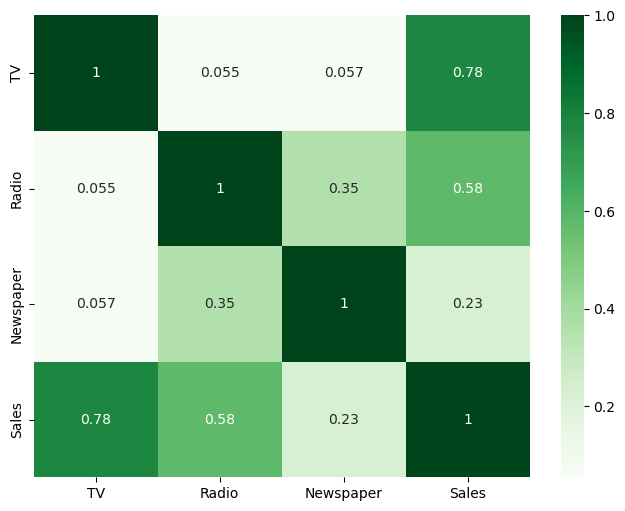

In [21]:
#eda
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="Greens")
plt.show()

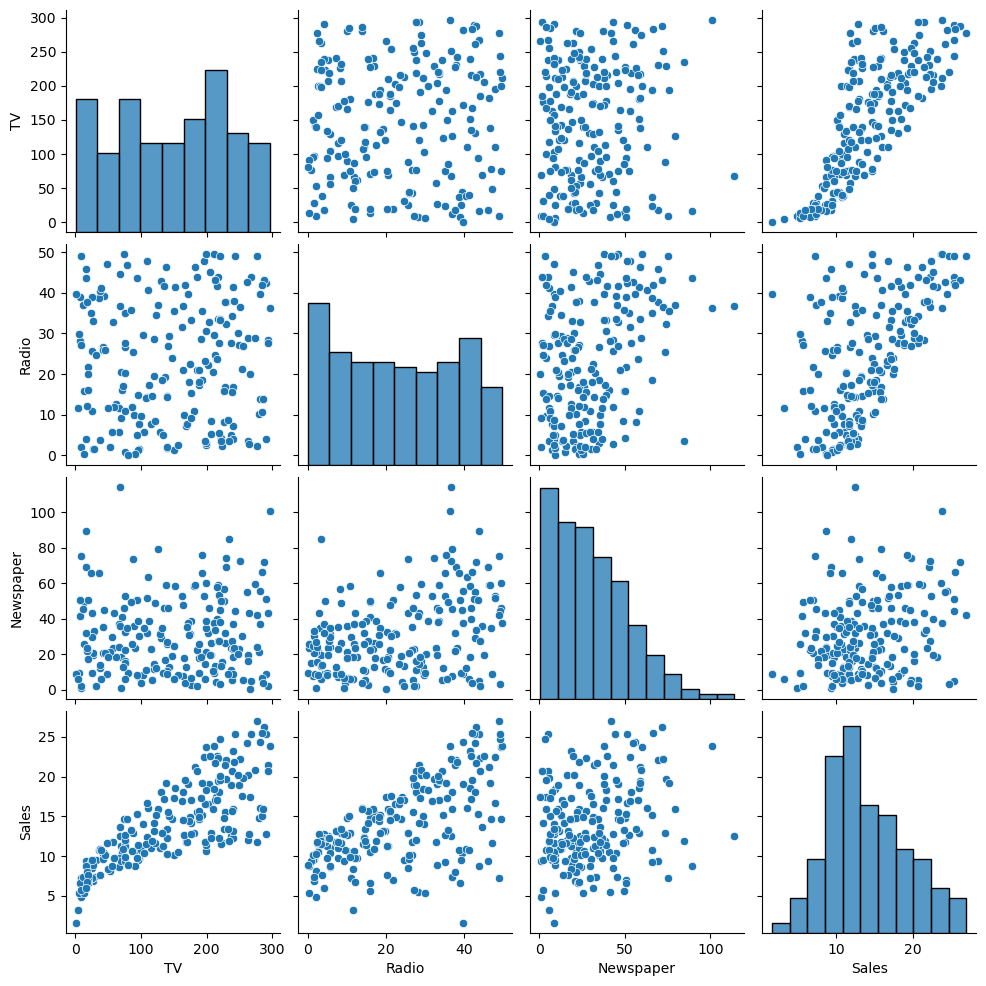

In [12]:
sns.pairplot(df)
plt.show()

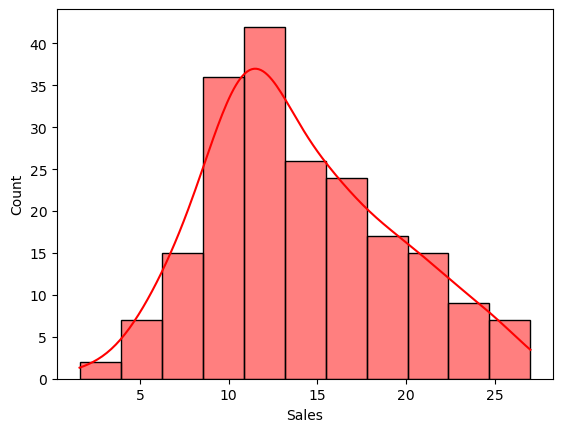

In [14]:
sns.histplot(df["Sales"], color="red",kde=True)
plt.show()

In [25]:
X = df.drop("Sales", axis=1)

In [26]:
y = df["Sales"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred = model.predict(X_test)

## Evaluation

In [30]:
#MAE 
mae = mean_absolute_error(y_test, y_pred)
print(mae)

1.4607567168117606


In [31]:
#MSE
mse = mean_squared_error(y_test, y_pred)
print(mse)

3.1740973539761046


In [32]:
#RMSE
rmse = np.sqrt(mse)
print(rmse)

1.7815996615334502


In [33]:
#RSQUARE SCORE
r2 = r2_score(y_test, y_pred)
print(r2)

0.899438024100912


In [36]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.4607567168117606
MSE: 3.1740973539761046
RMSE: 1.7815996615334502
R2 Score: 0.899438024100912


 SINCE RSQUARE SCORE CLOSE TO 1 WE ACHIEVED GOOD PREDICTION MODEL

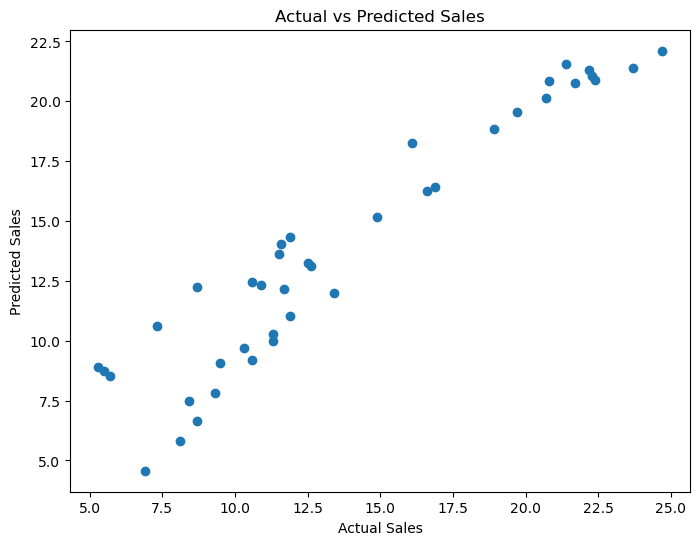

In [34]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [35]:
#NEW SALES PREDICTION
new_data = pd.DataFrame({
    "TV":[230],
    "Radio":[37],
    "Newspaper":[69]
})

prediction = model.predict(new_data)

print(prediction)

[20.45759025]


## Business Insights

TV advertising has the strongest positive impact on sales.
Radio advertising also improves sales but less than TV.
Newspaper advertising contributes comparatively less.
Increasing the TV advertising budget is likely to yield the highest increase in sales.
Businesses should prioritize TV campaigns while using Radio as a supporting channel for better returns.

## CONCLUSIONS

In this project, a Linear Regression model was developed to predict sales based on advertising expenditure across TV, Radio, and Newspaper channels. The dataset was cleaned, explored, and analyzed before training the model.

The model achieved an R² score of 0.8994, indicating that it explains approximately 89.94% of the variation in sales. The MAE of 1.46 and RMSE of 1.78 demonstrate that the predictions are reasonably close to the actual sales values.

The analysis showed that TV advertising has the strongest influence on sales, followed by Radio, while Newspaper advertising has the least impact. These findings suggest that businesses can improve sales by allocating a larger portion of their advertising budget to TV and Radio campaigns.